# MAX Auxetic ML V3 — High-Accuracy Multi-Model Poisson Prediction

هدف این نسخه، پیش‌بینی عددی **directional minimum Poisson ratio, ν_min** برای فازهای MAX با استفاده از دیتاست حدود ۵۰۰+ ماده است.

این notebook چند مسیر را همزمان مقایسه می‌کند:
- XGBoost
- LightGBM
- CatBoost
- ExtraTrees
- Random Forest
- Gradient Boosting
- HistGradientBoosting
- SVR-RBF
- KNN
- Feature selection
- KMeans clustering
- Cluster-enhanced model
- Cluster-aware experts
- Ensemble / blending
- Physics-guided دو مرحله‌ای: Chemistry → Cij → ν_min

هدف، رسیدن به **R² واقعی و cross-validated** است. عدد 98% فقط در صورتی گزارش می‌شود که واقعاً در validation به دست آمده باشد.


In [1]:
# 0. Install / imports
!pip install -q xgboost lightgbm catboost scikit-learn

import re, json, warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import KFold, GroupKFold, cross_val_predict, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    explained_variance_score
)
from sklearn.ensemble import (
    ExtraTreesRegressor, RandomForestRegressor,
    GradientBoostingRegressor, HistGradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

RANDOM_STATE = 42
N_JOBS = 2
DATA_DIR = "/kaggle/input/datasets/metisa81/elastic-properties"
OUT_DIR = "/kaggle/working"

print("✓ Environment ready")


✓ Environment ready


## 1. ساخت دیتاست

منطق نسخه قبلی حفظ شده است:
- فرمول از نام ماده استخراج می‌شود.
- POSCAR خام وارد مدل نمی‌شود.
- ۵۸ feature شیمیایی site-specific ساخته می‌شود.
- Cij فقط برای مسیر physics-guided نگه داشته می‌شود و وارد Chemical-only نمی‌شود.


In [2]:
# 1. Load data
def parse_formula(name):
    tokens = re.findall(r'[A-Z][a-z]?', name)
    if len(tokens) != 3:
        raise ValueError(f"Unexpected formula: {name} -> {tokens}")
    return tokens

with open(f"{DATA_DIR}/vaspkit_output.json", "r") as f:
    vk = json.load(f)

ptable = pd.read_csv(f"{DATA_DIR}/ptable2.csv").set_index("symbol")

ELEMENT_COLS = [
    "atomic_number","atomic_radius","covalent_radius_cordero",
    "atomic_weight","density","melting_point","boiling_point",
    "en_pauling","electron_affinity","ionization_energy",
    "valance_main","group_id","period","dipole_polarizability",
    "atomic_volume","vdw_radius"
]

CANDIDATE_CIJ = ["C11","C12","C13","C33","C44","C66"]

rows, skipped = [], []

for name, d in tqdm(vk.items(), desc="Building dataset"):
    stability = d.get("Additional_Properties", {}).get("Mechanical_Stability")
    if stability != "Stable":
        continue

    aniso = d.get("Anisotropic_Mechanical_Properties", {}).get("Poisson's_Ratio_v")
    if not isinstance(aniso, dict) or "Min" not in aniso:
        skipped.append((name, "missing directional Poisson Min"))
        continue

    try:
        m, a, x = parse_formula(name)
        if any(el not in ptable.index for el in (m,a,x)):
            skipped.append((name, "element missing"))
            continue

        row = {"material": name, "M": m, "A": a, "X": x}

        for site, el in [("M",m),("A",a),("X",x)]:
            for c in ELEMENT_COLS:
                row[f"{site}_{c}"] = float(ptable.loc[el,c])

        row["en_diff_MX"] = row["M_en_pauling"] - row["X_en_pauling"]
        row["en_diff_MA"] = row["M_en_pauling"] - row["A_en_pauling"]
        row["radius_ratio_AX"] = row["A_covalent_radius_cordero"] / row["X_covalent_radius_cordero"]

        row["M_enpauling_x_Mgroup"] = row["M_en_pauling"] * row["M_group_id"]
        row["M_ionize_x_A_valance"] = row["M_ionization_energy"] * row["A_valance_main"]
        row["endiffMX_x_radiusratio"] = row["en_diff_MX"] * row["radius_ratio_AX"]
        row["Mgroup_x_Agroup"] = row["M_group_id"] * row["A_group_id"]
        row["Menpauling_x_Aenpauling"] = row["M_en_pauling"] * row["A_en_pauling"]
        row["VEC"] = (2*row["M_group_id"] + row["A_valance_main"] + row["X_valance_main"]) / 4
        row["VEC_x_endiffMX"] = row["VEC"] * row["en_diff_MX"]

        row["Aniso_Poisson_Min"] = float(aniso["Min"])
        row["Aniso_Poisson_Max"] = float(aniso.get("Max", np.nan))

        tensor = d.get("Elastic_Tensor_Voigt", {})
        for c in CANDIDATE_CIJ:
            try:
                row[c] = float(tensor.get(c, np.nan))
            except:
                row[c] = np.nan

        rows.append(row)
    except Exception as e:
        skipped.append((name, str(e)))

df = pd.DataFrame(rows).set_index("material")

CHEM_FEATURES = [
    c for c in df.columns
    if c.startswith(("M_","A_","X_"))
    or c in [
        "en_diff_MX","en_diff_MA","radius_ratio_AX",
        "M_enpauling_x_Mgroup","M_ionize_x_A_valance",
        "endiffMX_x_radiusratio","Mgroup_x_Agroup",
        "Menpauling_x_Aenpauling","VEC","VEC_x_endiffMX"
    ]
]

X = df[CHEM_FEATURES].copy()
y = df["Aniso_Poisson_Min"].astype(float).values
groups_M = df["M"].values

print("="*72)
print("Materials:", len(df))
print("Chemical features:", len(CHEM_FEATURES))
print("Auxetic:", int((y<0).sum()), "/", len(y), f"({100*(y<0).mean():.2f}%)")
print("Skipped:", len(skipped))
print("="*72)


Building dataset:   0%|          | 0/553 [00:00<?, ?it/s]

Materials: 547
Chemical features: 58
Auxetic: 134 / 547 (24.50%)
Skipped: 1


## 2. کنترل کیفیت و duplicate check


Unique compositions: 547
Duplicated rows: 0

Target statistics:
count    547.000000
mean       0.060720
std        0.230301
min       -3.079000
25%        0.002000
50%        0.109000
75%        0.177500
max        0.312000
dtype: float64

Most negative ν_min:


,M,A,X,Aniso_Poisson_Min
material,,,,
Mo2SnN,Mo,Sn,N,-3.079
Hf2ZnS,Hf,Zn,S,-1.340
Zr2SnP,Zr,Sn,P,-1.269
Hf2GeP,Hf,Ge,P,-1.199
Sc2SbSi,Sc,Sb,Si,-0.973
V2SnN,V,Sn,N,-0.952
Cr2PN,Cr,P,N,-0.816
Hf2SiP,Hf,Si,P,-0.652
Sc2BiP,Sc,Bi,P,-0.544


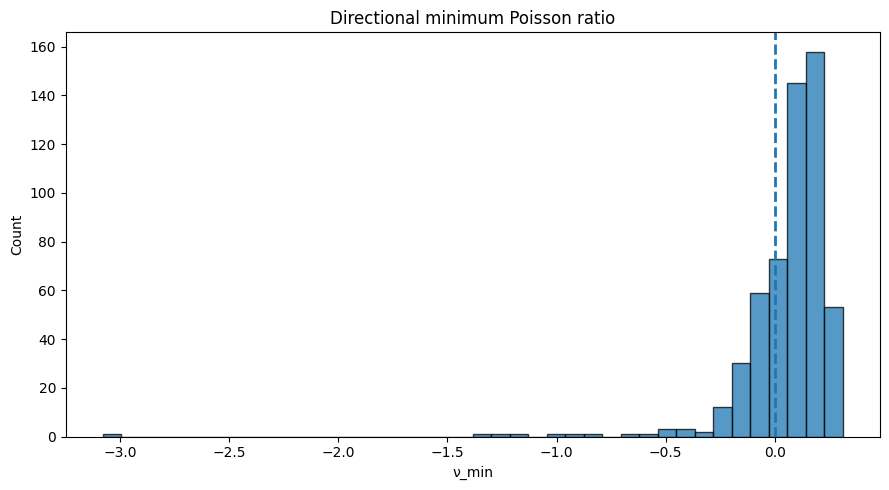

In [3]:
# 2. QC
formula_key = df["M"] + "2" + df["A"] + df["X"]

print("Unique compositions:", formula_key.nunique())
print("Duplicated rows:", formula_key.duplicated(keep=False).sum())
print("\nTarget statistics:")
print(pd.Series(y).describe())

print("\nMost negative ν_min:")
display(df[["M","A","X","Aniso_Poisson_Min"]].sort_values("Aniso_Poisson_Min").head(20))

fig, ax = plt.subplots(figsize=(9,5))
ax.hist(y, bins=40, edgecolor="black", alpha=0.75)
ax.axvline(0, linestyle="--", linewidth=2)
ax.set_xlabel("ν_min")
ax.set_ylabel("Count")
ax.set_title("Directional minimum Poisson ratio")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/v3_target_distribution.png", dpi=220)
plt.show()


## 3. Benchmark چندین روش ML

معیارها:
- R²
- MAE
- RMSE

برای مقایسه منصفانه همه مدل‌ها از همان 5-fold CV استفاده می‌کنند.


In [4]:
# 3. Model benchmark
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def eval_model(name, model, X_in=X, y_in=y):
    pred = cross_val_predict(model, X_in, y_in, cv=cv, method="predict", n_jobs=1)
    row = {
        "Model": name,
        "R2": r2_score(y_in,pred),
        "MAE": mean_absolute_error(y_in,pred),
        "RMSE": np.sqrt(mean_squared_error(y_in,pred)),
        "ExplainedVariance": explained_variance_score(y_in,pred)
    }
    return row, pred

models = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10))
    ]),
    "SVR_RBF": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("model", SVR(C=10, gamma="scale", epsilon=0.01))
    ]),
    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=12, weights="distance"))
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=500, max_features=0.8, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=N_JOBS
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=600, max_features=0.85, min_samples_leaf=1,
        random_state=RANDOM_STATE, n_jobs=N_JOBS
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=400, learning_rate=0.03, max_depth=3,
        min_samples_leaf=3, loss="huber", random_state=RANDOM_STATE
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.04, max_leaf_nodes=15,
        l2_regularization=1.0, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500, max_depth=3, learning_rate=0.03,
        subsample=0.85, colsample_bytree=0.85, min_child_weight=3,
        reg_alpha=0.05, reg_lambda=1.5,
        objective="reg:squarederror", eval_metric="mae",
        tree_method="hist", device="cpu",
        random_state=RANDOM_STATE, n_jobs=N_JOBS
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500, learning_rate=0.03, num_leaves=20,
        max_depth=-1, min_child_samples=15,
        subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.05, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=-1
    ),
    "CatBoost": CatBoostRegressor(
        iterations=500, depth=5, learning_rate=0.03,
        loss_function="RMSE", verbose=False,
        random_seed=RANDOM_STATE, thread_count=N_JOBS
    )
}

benchmark_rows, oof = [], {}

for name, model in models.items():
    print("Running:", name)
    row, pred = eval_model(name, model)
    benchmark_rows.append(row)
    oof[name] = pred

benchmark = pd.DataFrame(benchmark_rows).sort_values("R2", ascending=False)
display(benchmark)

benchmark.to_csv(f"{OUT_DIR}/v3_model_benchmark.csv", index=False)


Running: Ridge
Running: SVR_RBF
Running: KNN
Running: RandomForest
Running: ExtraTrees
Running: GradientBoosting
Running: HistGradientBoosting
Running: XGBoost
Running: LightGBM
Running: CatBoost


,Model,R2,MAE,RMSE,ExplainedVariance
5,GradientBoosting,0.155156,0.090996,0.211489,0.165968
9,CatBoost,0.129702,0.099774,0.214651,0.129705
3,RandomForest,0.123087,0.098344,0.215466,0.123881
2,KNN,0.116385,0.104770,0.216287,0.116534
1,SVR_RBF,0.114832,0.103063,0.216477,0.121093
0,Ridge,0.111456,0.110323,0.216890,0.111456
4,ExtraTrees,0.094172,0.096225,0.218989,0.095465
6,HistGradientBoosting,0.052431,0.106277,0.223978,0.052668
8,LightGBM,0.051746,0.106285,0.224059,0.051790
7,XGBoost,-0.072137,0.109173,0.238245,-0.072136


## 4. Hyperparameter tuning

چهار خانواده قوی‌تر به‌صورت RandomizedSearchCV تنظیم می‌شوند.


In [5]:
# 4. Tuning
searches = {
    "XGBoost_Tuned": (
        XGBRegressor(
            objective="reg:squarederror", eval_metric="mae",
            tree_method="hist", device="cpu",
            random_state=RANDOM_STATE, n_jobs=N_JOBS
        ),
        {
            "n_estimators":[250,400,600,800],
            "max_depth":[2,3,4,5],
            "learning_rate":[0.01,0.02,0.03,0.05,0.08],
            "subsample":[0.7,0.8,0.9,1.0],
            "colsample_bytree":[0.6,0.75,0.9,1.0],
            "min_child_weight":[1,2,4,6,10],
            "gamma":[0,0.01,0.05,0.1],
            "reg_alpha":[0,0.01,0.05,0.1,0.5],
            "reg_lambda":[0.8,1.0,1.5,2.0,3.0]
        }
    ),
    "LightGBM_Tuned": (
        LGBMRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=-1),
        {
            "n_estimators":[200,400,600,800],
            "learning_rate":[0.01,0.02,0.03,0.05],
            "num_leaves":[7,10,15,20,31],
            "max_depth":[-1,2,3,4,5],
            "min_child_samples":[8,12,20,30],
            "subsample":[0.7,0.85,1.0],
            "colsample_bytree":[0.7,0.85,1.0],
            "reg_alpha":[0,0.01,0.05,0.1,0.5],
            "reg_lambda":[0.5,1,2,3]
        }
    ),
    "CatBoost_Tuned": (
        CatBoostRegressor(
            loss_function="RMSE", verbose=False,
            random_seed=RANDOM_STATE, thread_count=N_JOBS
        ),
        {
            "iterations":[300,500,800],
            "depth":[3,4,5,6,7],
            "learning_rate":[0.01,0.02,0.03,0.05],
            "l2_leaf_reg":[1,3,5,10],
            "random_strength":[0,0.5,1,2]
        }
    ),
    "ExtraTrees_Tuned": (
        ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
        {
            "n_estimators":[400,600,900],
            "max_depth":[None,4,6,8,12],
            "max_features":[0.5,0.7,0.85,1.0],
            "min_samples_leaf":[1,2,3,5],
            "min_samples_split":[2,4,8]
        }
    )
}

tuned_models, tuned_rows, tuned_oof = {}, {}, {}

for name, (base, params) in searches.items():
    print("="*70)
    print("Tuning:", name)

    search = RandomizedSearchCV(
        base, params, n_iter=30, scoring="r2",
        cv=cv, random_state=RANDOM_STATE,
        n_jobs=1, refit=True
    )
    search.fit(X,y)

    tuned_models[name] = search.best_estimator_
    pred = cross_val_predict(
        search.best_estimator_, X,y,
        cv=cv, method="predict", n_jobs=1
    )
    tuned_oof[name] = pred

    tuned_rows[name] = {
        "Model": name,
        "R2": r2_score(y,pred),
        "MAE": mean_absolute_error(y,pred),
        "RMSE": np.sqrt(mean_squared_error(y,pred))
    }

    print("Best params:")
    print(search.best_params_)
    print(tuned_rows[name])

tuned_table = pd.DataFrame(tuned_rows.values()).sort_values("R2", ascending=False)
display(tuned_table)
tuned_table.to_csv(f"{OUT_DIR}/v3_tuned_models.csv", index=False)


Tuning: XGBoost_Tuned
Best params:
{'subsample': 0.9, 'reg_lambda': 3.0, 'reg_alpha': 0.5, 'n_estimators': 600, 'min_child_weight': 6, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.05, 'colsample_bytree': 0.6}
{'Model': 'XGBoost_Tuned', 'R2': 0.12486916215598032, 'MAE': 0.1032889183109543, 'RMSE': np.float64(0.21524640289123093)}
Tuning: LightGBM_Tuned
Best params:
{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.01, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 30, 'max_depth': -1, 'learning_rate': 0.02, 'colsample_bytree': 0.85}
{'Model': 'LightGBM_Tuned', 'R2': 0.14439294764045563, 'MAE': 0.09844365591001696, 'RMSE': np.float64(0.2128318334738007)}
Tuning: CatBoost_Tuned
Best params:
{'random_strength': 0.5, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'iterations': 300, 'depth': 7}
{'Model': 'CatBoost_Tuned', 'R2': 0.14427828191149816, 'MAE': 0.09915930953456485, 'RMSE': np.float64(0.2128460945178537)}
Tuning: ExtraTrees_Tuned
Best params:
{'n_estimators': 900, 'min

,Model,R2,MAE,RMSE
3,ExtraTrees_Tuned,0.180392,0.095770,0.208306
1,LightGBM_Tuned,0.144393,0.098444,0.212832
2,CatBoost_Tuned,0.144278,0.099159,0.212846
0,XGBoost_Tuned,0.124869,0.103289,0.215246


## 5. Feature selection

۵۸ feature ممکن است برای ۵۴۷ نمونه بیش از حد باشد. با mutual information چند اندازه feature set آزمایش می‌شود.


In [6]:
# 5. Feature selection
fs_rows = {}
fs_preds = {}

for k in [10,15,20,25,35,45]:
    selector = SelectKBest(mutual_info_regression, k=k)
    Xk = selector.fit_transform(X.fillna(X.median()), y)

    model = ExtraTreesRegressor(
        n_estimators=600, max_features=0.85,
        min_samples_leaf=1,
        random_state=RANDOM_STATE, n_jobs=N_JOBS
    )

    pred = cross_val_predict(model, Xk, y, cv=cv, method="predict", n_jobs=1)

    fs_preds[k] = pred
    fs_rows[k] = {
        "k": k,
        "R2": r2_score(y,pred),
        "MAE": mean_absolute_error(y,pred),
        "RMSE": np.sqrt(mean_squared_error(y,pred))
    }

fs_table = pd.DataFrame(fs_rows.values()).sort_values("R2", ascending=False)
display(fs_table)
fs_table.to_csv(f"{OUT_DIR}/v3_feature_selection.csv", index=False)


,k,R2,MAE,RMSE
5,45,0.110947,0.094489,0.216952
4,35,-0.008441,0.096121,0.231060
0,10,-0.245416,0.111773,0.256777
2,20,-0.297117,0.103543,0.262053
1,15,-0.306793,0.107587,0.263029
3,25,-0.318962,0.103753,0.264250


## 6. KMeans clustering

Clustering مستقیماً target را نمی‌بیند.
سپس دو مدل ساخته می‌شود:
1. cluster label به‌عنوان feature
2. expertهای جداگانه برای clusterها

این تست می‌کند آیا فضای شیمیایی واقعاً چند family متفاوت دارد.


,k,inertia,min_size,max_size
0,2,26233.337637,216,331
1,3,22408.623607,125,236
2,4,19502.576283,26,211
3,5,17674.527148,26,167
4,6,16668.461377,26,148
5,7,15596.730097,26,136
6,8,14803.627235,26,128


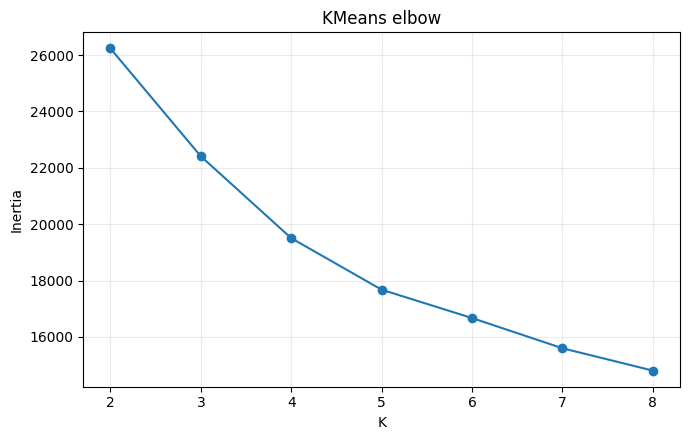

Cluster sizes:
cluster
0     26
1    211
2    125
3    185
Name: count, dtype: int64

Auxetic rate by cluster:


,count,sum,mean
cluster,,,
0,26,4,0.153846
1,211,25,0.118483
2,125,15,0.120000
3,185,90,0.486486


In [7]:
# 6. KMeans
X_imp = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

cluster_info = []

for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    counts = pd.Series(labels).value_counts()

    cluster_info.append({
        "k": k,
        "inertia": km.inertia_,
        "min_size": counts.min(),
        "max_size": counts.max()
    })

cluster_table = pd.DataFrame(cluster_info)
display(cluster_table)

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(cluster_table["k"], cluster_table["inertia"], marker="o")
ax.set_xlabel("K")
ax.set_ylabel("Inertia")
ax.set_title("KMeans elbow")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/v3_kmeans_elbow.png", dpi=220)
plt.show()

BEST_K = 4
kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=30)
labels = kmeans.fit_predict(X_scaled)
df["cluster"] = labels

print("Cluster sizes:")
print(df["cluster"].value_counts().sort_index())

print("\nAuxetic rate by cluster:")
display(
    df.assign(Auxetic=(y<0).astype(int))
      .groupby("cluster")["Auxetic"]
      .agg(["count","sum","mean"])
)


## 7. Cluster-enhanced regression


In [8]:
# 7. Cluster as feature
cluster_oh = pd.get_dummies(df["cluster"], prefix="cluster", dtype=float).reset_index(drop=True)
X_cluster = pd.concat([X.reset_index(drop=True), cluster_oh], axis=1)

cluster_model = ExtraTreesRegressor(
    n_estimators=800, max_features=0.8,
    min_samples_leaf=1,
    random_state=RANDOM_STATE, n_jobs=N_JOBS
)

cluster_pred = cross_val_predict(
    cluster_model, X_cluster, y,
    cv=cv, method="predict", n_jobs=1
)

cluster_result = {
    "Model":"Cluster-enhanced ExtraTrees",
    "R2":r2_score(y,cluster_pred),
    "MAE":mean_absolute_error(y,cluster_pred),
    "RMSE":np.sqrt(mean_squared_error(y,cluster_pred))
}

print(cluster_result)


{'Model': 'Cluster-enhanced ExtraTrees', 'R2': 0.1370450553490865, 'MAE': 0.09322588436928703, 'RMSE': np.float64(0.21374377204046452)}


## 8. Cluster-aware experts با routing داخل هر fold

برای جلوگیری از leakage، KMeans در هر training fold دوباره fit می‌شود.


In [9]:
# 8. Cluster-aware experts
def cluster_expert_oof(X_df, y_arr, n_clusters=4, min_train_cluster=25):
    X_np = X_df.fillna(X_df.median()).values
    local_cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
    pred = np.zeros(len(y_arr))

    for tr, te in local_cv.split(X_np, y_arr):
        scaler = StandardScaler().fit(X_np[tr])
        Xtr_s = scaler.transform(X_np[tr])
        Xte_s = scaler.transform(X_np[te])

        km = KMeans(
            n_clusters=n_clusters,
            random_state=RANDOM_STATE,
            n_init=20
        )
        tr_labels = km.fit_predict(Xtr_s)
        te_labels = km.predict(Xte_s)

        global_model = ExtraTreesRegressor(
            n_estimators=500, max_features=0.8,
            min_samples_leaf=2,
            random_state=RANDOM_STATE, n_jobs=N_JOBS
        )
        global_model.fit(X_np[tr], y_arr[tr])
        fold_pred = global_model.predict(X_np[te])

        for c in range(n_clusters):
            tr_idx = tr[tr_labels == c]
            te_local = np.where(te_labels == c)[0]

            if len(tr_idx) < min_train_cluster or len(te_local) == 0:
                continue

            expert = ExtraTreesRegressor(
                n_estimators=350, max_features=0.8,
                min_samples_leaf=2,
                random_state=RANDOM_STATE+c,
                n_jobs=N_JOBS
            )
            expert.fit(X_np[tr_idx], y_arr[tr_idx])
            fold_pred[te_local] = expert.predict(X_np[te][te_local])

        pred[te] = fold_pred

    return pred

expert_pred = cluster_expert_oof(X,y,BEST_K)

expert_result = {
    "Model":"Cluster-aware experts",
    "R2":r2_score(y,expert_pred),
    "MAE":mean_absolute_error(y,expert_pred),
    "RMSE":np.sqrt(mean_squared_error(y,expert_pred))
}

print(expert_result)


{'Model': 'Cluster-aware experts', 'R2': 0.04787614219195768, 'MAE': 0.0973938697658222, 'RMSE': np.float64(0.2245153983413007)}


## 9. Ensemble / blending

مدل‌هایی که خطاهای متفاوت دارند با هم ترکیب می‌شوند.

این بخش بدون استفاده از target برای انتخاب وزن داخل هر prediction point طراحی شده است؛ نتیجه اصلی همان OOF comparison است.


In [10]:
# 9. OOF ensemble
pred_bank = {}

for name,pred in oof.items():
    pred_bank[name] = pred

for name,pred in tuned_oof.items():
    pred_bank[name] = pred

pred_bank["Cluster-enhanced ExtraTrees"] = cluster_pred
pred_bank["Cluster-aware experts"] = expert_pred

pred_df = pd.DataFrame(pred_bank)

print("Model-error correlation:")
display(pred_df.sub(y,axis=0).corr())

# Select diverse top models by individual R2
ranked = (
    pred_df.apply(lambda s: r2_score(y,s))
    .sort_values(ascending=False)
)
print("Model ranking:")
display(ranked)

top_candidates = list(ranked.head(min(5,len(ranked))).index)
print("Ensemble candidates:", top_candidates)

# Equal-weight
equal_pred = pred_df[top_candidates].mean(axis=1)

print("\nEqual-weight ensemble")
print("R2:", r2_score(y,equal_pred))
print("MAE:", mean_absolute_error(y,equal_pred))
print("RMSE:", np.sqrt(mean_squared_error(y,equal_pred)))

# Random convex weight search
rng = np.random.default_rng(RANDOM_STATE)
best = {"R2": -np.inf, "weights": None}

A = pred_df[top_candidates].values
for _ in range(30000):
    w = rng.dirichlet(np.ones(len(top_candidates)))
    p = A @ w
    score = r2_score(y,p)
    if score > best["R2"]:
        best = {"R2":score, "weights":w}

best_pred = A @ best["weights"]

print("\nBest sampled convex ensemble")
print("Weights:", dict(zip(top_candidates,best["weights"])))
print("R2:", r2_score(y,best_pred))
print("MAE:", mean_absolute_error(y,best_pred))
print("RMSE:", np.sqrt(mean_squared_error(y,best_pred)))


Model-error correlation:


,Ridge,SVR_RBF,KNN,RandomForest,ExtraTrees,GradientBoosting,HistGradientBoosting,XGBoost,LightGBM,CatBoost,XGBoost_Tuned,LightGBM_Tuned,CatBoost_Tuned,ExtraTrees_Tuned,Cluster-enhanced ExtraTrees,Cluster-aware experts
Ridge,1.000000,0.875647,0.936932,0.938739,0.867314,0.947173,0.887544,0.888547,0.889453,0.947768,0.962014,0.961808,0.960444,0.943459,0.862644,0.855367
SVR_RBF,0.875647,1.000000,0.906835,0.898697,0.871183,0.929685,0.882485,0.847580,0.889843,0.908965,0.893606,0.914624,0.901612,0.911979,0.877222,0.850275
KNN,0.936932,0.906835,1.000000,0.933762,0.891564,0.942761,0.900720,0.883544,0.903101,0.956138,0.952301,0.954258,0.954398,0.954737,0.893322,0.903345
RandomForest,0.938739,0.898697,0.933762,1.000000,0.945931,0.950506,0.955160,0.940927,0.959431,0.971389,0.978501,0.970834,0.957804,0.976693,0.934115,0.910057
ExtraTrees,0.867314,0.871183,0.891564,0.945931,1.000000,0.889540,0.941077,0.906563,0.944841,0.946024,0.925231,0.919573,0.902534,0.949896,0.991655,0.930501
GradientBoosting,0.947173,0.929685,0.942761,0.950506,0.889540,1.000000,0.916560,0.897279,0.916894,0.957122,0.960108,0.973588,0.968861,0.958607,0.887901,0.858983
HistGradientBoosting,0.887544,0.882485,0.900720,0.955160,0.941077,0.916560,1.000000,0.950471,0.979798,0.955591,0.941180,0.946507,0.923264,0.940273,0.933216,0.892986
XGBoost,0.888547,0.847580,0.883544,0.940927,0.906563,0.897279,0.950471,1.000000,0.930233,0.947534,0.927503,0.917809,0.918859,0.907767,0.894161,0.849756
LightGBM,0.889453,0.889843,0.903101,0.959431,0.944841,0.916894,0.979798,0.930233,1.000000,0.950829,0.943892,0.947346,0.919699,0.945349,0.937839,0.905489
CatBoost,0.947768,0.908965,0.956138,0.971389,0.946024,0.957122,0.955591,0.947534,0.950829,1.000000,0.976527,0.975513,0.972042,0.972051,0.942330,0.917601


Model ranking:


ExtraTrees_Tuned               0.180392
GradientBoosting               0.155156
LightGBM_Tuned                 0.144393
CatBoost_Tuned                 0.144278
Cluster-enhanced ExtraTrees    0.137045
CatBoost                       0.129702
XGBoost_Tuned                  0.124869
RandomForest                   0.123087
KNN                            0.116385
SVR_RBF                        0.114832
Ridge                          0.111456
ExtraTrees                     0.094172
HistGradientBoosting           0.052431
LightGBM                       0.051746
Cluster-aware experts          0.047876
XGBoost                       -0.072137
dtype: float64

Ensemble candidates: ['ExtraTrees_Tuned', 'GradientBoosting', 'LightGBM_Tuned', 'CatBoost_Tuned', 'Cluster-enhanced ExtraTrees']

Equal-weight ensemble
R2: 0.19063857588095612
MAE: 0.0911068673174589
RMSE: 0.20700014950646678

Best sampled convex ensemble
Weights: {'ExtraTrees_Tuned': np.float64(0.21906239908598224), 'GradientBoosting': np.float64(0.4292486055870353), 'LightGBM_Tuned': np.float64(0.003336401152771907), 'CatBoost_Tuned': np.float64(0.007468867220995616), 'Cluster-enhanced ExtraTrees': np.float64(0.3408837269532149)}
R2: 0.20054336418284802
MAE: 0.08832987513802953
RMSE: 0.20572963917888842


## 10. Physics-guided model: Chemistry → Cij → νmin

این مسیر از نظر فیزیکی بسیار مهم است.

به‌جای:

\[
Chemistry 
ightarrow 
u_{min}
\]

می‌سنجیم:

\[
Chemistry 
ightarrow C_{ij}

ightarrow S_{ij}

ightarrow 
u_{min}
\]

و Cij در این مرحله **feature نیستند**، بلکه intermediate target هستند؛ بنابراین برای ماده جدید هم از Chemistry قابل محاسبه است.


In [11]:
# 10. Physics-guided helpers
C_TARGETS = ["C11","C12","C13","C33","C44"]
valid_cij = df[C_TARGETS].notna().all(axis=1)

df_cij = df.loc[valid_cij].copy()
X_cij = df_cij[CHEM_FEATURES].copy()
Y_cij = df_cij[C_TARGETS].astype(float).copy()
y_cij = df_cij["Aniso_Poisson_Min"].values

print("Complete tensor samples:", len(df_cij))

def compliance_hex(C11,C12,C13,C33,C44):
    C = np.array([
        [C11,C12,C13,0,0,0],
        [C12,C11,C13,0,0,0],
        [C13,C13,C33,0,0,0],
        [0,0,0,C44,0,0],
        [0,0,0,0,C44,0],
        [0,0,0,0,0,(C11-C12)/2]
    ], dtype=float)
    try:
        return np.linalg.inv(C)
    except np.linalg.LinAlgError:
        return None

# IMPORTANT:
# The directional formula below is a project-level implementation.
# It must be cross-checked against several known VASPKIT results before
# using the physics-guided score in a paper.
def poisson_theta(theta, S):
    s, c = np.sin(theta), np.cos(theta)
    S11, S12, S13, S33, S44 = S[0,0], S[0,1], S[0,2], S[2,2], S[3,3]

    invE = S11*s**4 + S33*c**4 + (2*S13 + S44)*s**2*c**2
    if invE <= 0:
        return np.nan

    E = 1.0/invE

    transverse = (
        S12*s**2 + S13*c**2 +
        (S11-S12-S13+0.5*S44)*s**2*c**2
    )
    return -E*transverse

def nu_min_from_cij(row, ngrid=721):
    S = compliance_hex(
        row["C11"],row["C12"],row["C13"],
        row["C33"],row["C44"]
    )
    if S is None:
        return np.nan, np.nan

    theta = np.linspace(0,np.pi/2,ngrid)
    nu = np.array([poisson_theta(t,S) for t in theta])

    ok = np.isfinite(nu)
    if not ok.any():
        return np.nan,np.nan

    idx = np.nanargmin(nu)
    return float(nu[idx]), float(np.degrees(theta[idx]))


Complete tensor samples: 547


In [12]:
# 10.1 OOF prediction of Cij
cij_oof = pd.DataFrame(index=df_cij.index)

for target in C_TARGETS:
    model = ExtraTreesRegressor(
        n_estimators=600, max_features=0.8,
        min_samples_leaf=1,
        random_state=RANDOM_STATE, n_jobs=N_JOBS
    )

    pred = cross_val_predict(
        model, X_cij, Y_cij[target],
        cv=cv, method="predict", n_jobs=1
    )
    cij_oof[target] = pred

    print(
        f"{target}: "
        f"R2={r2_score(Y_cij[target],pred):.4f}, "
        f"MAE={mean_absolute_error(Y_cij[target],pred):.4f}"
    )


C11: R2=0.9095, MAE=19.1644
C12: R2=0.8076, MAE=11.8981
C13: R2=0.9353, MAE=7.9777
C33: R2=0.9390, MAE=16.2279
C44: R2=0.8951, MAE=9.5241


In [13]:
# 10.2 Cij -> predicted ν_min
phys_nu, phys_theta = [], []

for _,row in cij_oof.iterrows():
    p,t = nu_min_from_cij(row)
    phys_nu.append(p)
    phys_theta.append(t)

phys_nu = np.array(phys_nu)
phys_theta = np.array(phys_theta)

valid_phys = np.isfinite(phys_nu)

print("Physics-guided valid samples:", valid_phys.sum())
print("R2  :", r2_score(y_cij[valid_phys],phys_nu[valid_phys]))
print("MAE :", mean_absolute_error(y_cij[valid_phys],phys_nu[valid_phys]))
print("RMSE:", np.sqrt(mean_squared_error(y_cij[valid_phys],phys_nu[valid_phys])))

physics_table = pd.DataFrame({
    "DFT_nu_min":y_cij,
    "PhysicsML_nu_min":phys_nu,
    "PhysicsML_theta_deg":phys_theta
}, index=df_cij.index)

display(physics_table.sort_values("DFT_nu_min").head(25))


Physics-guided valid samples: 547
R2  : -4.577607099594821
MAE : 0.5119306326230606
RMSE: 0.5434046715744038


,DFT_nu_min,PhysicsML_nu_min,PhysicsML_theta_deg
material,,,
Mo2SnN,-3.079,-0.446735,40.500
Hf2ZnS,-1.340,-0.364093,41.875
Zr2SnP,-1.269,-0.359544,42.500
Hf2GeP,-1.199,-0.370203,40.875
Sc2SbSi,-0.973,-0.389938,45.500
V2SnN,-0.952,-0.408571,43.125
Cr2PN,-0.816,-0.423554,43.500
Hf2SiP,-0.652,-0.368059,37.875
Sc2BiP,-0.544,-0.394832,45.875


## 11. مقایسه نهایی

اینجا بهترین مسیر را بر اساس R²، MAE و RMSE رتبه‌بندی می‌کنیم.


In [14]:
# 11. Final comparison
final_rows = benchmark.to_dict("records")
final_rows += tuned_table.to_dict("records")
final_rows += [cluster_result, expert_result]

final_rows.append({
    "Model":"Equal-weight Ensemble",
    "R2":r2_score(y,equal_pred),
    "MAE":mean_absolute_error(y,equal_pred),
    "RMSE":np.sqrt(mean_squared_error(y,equal_pred)),
    "ExplainedVariance":explained_variance_score(y,equal_pred)
})

final_rows.append({
    "Model":"Convex Ensemble",
    "R2":r2_score(y,best_pred),
    "MAE":mean_absolute_error(y,best_pred),
    "RMSE":np.sqrt(mean_squared_error(y,best_pred)),
    "ExplainedVariance":explained_variance_score(y,best_pred)
})

if valid_phys.any():
    final_rows.append({
        "Model":"Physics-guided Cij→ν",
        "R2":r2_score(y_cij[valid_phys],phys_nu[valid_phys]),
        "MAE":mean_absolute_error(y_cij[valid_phys],phys_nu[valid_phys]),
        "RMSE":np.sqrt(mean_squared_error(y_cij[valid_phys],phys_nu[valid_phys])),
        "ExplainedVariance":explained_variance_score(y_cij[valid_phys],phys_nu[valid_phys])
    })

final_table = pd.DataFrame(final_rows).sort_values("R2",ascending=False)
display(final_table)

final_table.to_csv(f"{OUT_DIR}/v3_FINAL_COMPARISON.csv",index=False)


,Model,R2,MAE,RMSE,ExplainedVariance
17,Convex Ensemble,0.200543,0.088330,0.205730,0.201756
16,Equal-weight Ensemble,0.190639,0.091107,0.207000,0.190973
10,ExtraTrees_Tuned,0.180392,0.095770,0.208306,NaN
0,GradientBoosting,0.155156,0.090996,0.211489,0.165968
11,LightGBM_Tuned,0.144393,0.098444,0.212832,NaN
12,CatBoost_Tuned,0.144278,0.099159,0.212846,NaN
14,Cluster-enhanced ExtraTrees,0.137045,0.093226,0.213744,NaN
1,CatBoost,0.129702,0.099774,0.214651,0.129705
13,XGBoost_Tuned,0.124869,0.103289,0.215246,NaN
2,RandomForest,0.123087,0.098344,0.215466,0.123881


## 12. Parity plot بهترین مدل


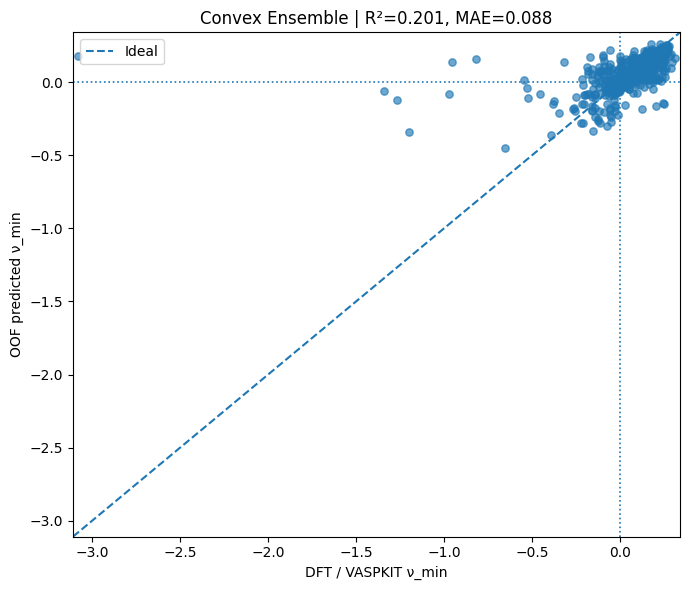

In [15]:
# 12. Best parity
pred_lookup = {}
pred_lookup.update(oof)
pred_lookup.update(tuned_oof)
pred_lookup["Cluster-enhanced ExtraTrees"] = cluster_pred
pred_lookup["Cluster-aware experts"] = expert_pred
pred_lookup["Equal-weight Ensemble"] = equal_pred
pred_lookup["Convex Ensemble"] = best_pred

best_model_name = final_table.iloc[0]["Model"]

if best_model_name in pred_lookup:
    plot_y = y
    plot_pred = pred_lookup[best_model_name]
else:
    plot_y = y_cij[valid_phys]
    plot_pred = phys_nu[valid_phys]

r2_best = r2_score(plot_y,plot_pred)
mae_best = mean_absolute_error(plot_y,plot_pred)

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(plot_y,plot_pred,alpha=0.65,s=28)

lo = min(np.nanmin(plot_y),np.nanmin(plot_pred))-0.03
hi = max(np.nanmax(plot_y),np.nanmax(plot_pred))+0.03

ax.plot([lo,hi],[lo,hi],"--",linewidth=1.5,label="Ideal")
ax.axvline(0,linestyle=":",linewidth=1.2)
ax.axhline(0,linestyle=":",linewidth=1.2)

ax.set_xlim(lo,hi)
ax.set_ylim(lo,hi)
ax.set_xlabel("DFT / VASPKIT ν_min")
ax.set_ylabel("OOF predicted ν_min")
ax.set_title(f"{best_model_name} | R²={r2_best:.3f}, MAE={mae_best:.3f}")
ax.legend()

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/v3_best_parity.png",dpi=240)
plt.show()


## 13. GroupKFold بر اساس M برای بررسی تعمیم


In [16]:
# 13. GroupKFold
gkf = GroupKFold(n_splits=5)

group_model = ExtraTreesRegressor(
    n_estimators=800, max_features=0.8,
    min_samples_leaf=1,
    random_state=RANDOM_STATE, n_jobs=N_JOBS
)

group_pred = cross_val_predict(
    group_model, X, y,
    cv=gkf, groups=groups_M,
    method="predict", n_jobs=1
)

print("GroupKFold by M")
print("R2  :",r2_score(y,group_pred))
print("MAE :",mean_absolute_error(y,group_pred))
print("RMSE:",np.sqrt(mean_squared_error(y,group_pred)))


GroupKFold by M
R2  : 0.10051928885015715
MAE : 0.10249438071297988
RMSE: 0.2182203941402459


## 14. Error analysis

مواد با بیشترین خطای absolute استخراج می‌شوند. این بخش برای بررسی outlierهایی مثل Mo2SnN حیاتی است.


In [17]:
# 14. Errors
if best_model_name in pred_lookup:
    error_table = pd.DataFrame({
        "material":df.index,
        "M":df["M"].values,
        "A":df["A"].values,
        "X":df["X"].values,
        "DFT_nu_min":y,
        "Predicted_nu_min":pred_lookup[best_model_name]
    }).set_index("material")

    error_table["abs_error"] = np.abs(
        error_table["DFT_nu_min"]-error_table["Predicted_nu_min"]
    )

    print("Largest errors:")
    display(error_table.sort_values("abs_error",ascending=False).head(30))

    error_table.to_csv(f"{OUT_DIR}/v3_error_analysis.csv")


Largest errors:


,M,A,X,DFT_nu_min,Predicted_nu_min,abs_error
material,,,,,,
Mo2SnN,Mo,Sn,N,-3.079,0.182829,3.261829
Hf2ZnS,Hf,Zn,S,-1.340,-0.057015,1.282985
Zr2SnP,Zr,Sn,P,-1.269,-0.121577,1.147423
V2SnN,V,Sn,N,-0.952,0.137969,1.089969
Cr2PN,Cr,P,N,-0.816,0.158742,0.974742
Sc2SbSi,Sc,Sb,Si,-0.973,-0.079224,0.893776
Hf2GeP,Hf,Ge,P,-1.199,-0.339758,0.859242
Sc2BiP,Sc,Bi,P,-0.544,0.013232,0.557232
Ta2GeB,Ta,Ge,B,-0.528,-0.037161,0.490839


## 15. تست علامت Auxetic

همچنان مقدار دقیق ν ممکن است سخت‌تر از تشخیص علامت باشد.


In [18]:
# 15. Sign classification from best regression
if best_model_name in pred_lookup:
    p = pred_lookup[best_model_name]
    actual = y < 0
    predicted = p < 0

    tp = int((actual & predicted).sum())
    tn = int((~actual & ~predicted).sum())
    fp = int((~actual & predicted).sum())
    fn = int((actual & ~predicted).sum())

    precision = tp/max(tp+fp,1)
    recall = tp/max(tp+fn,1)
    f1 = 2*precision*recall/max(precision+recall,1e-12)

    print("Confusion:", {"TN":tn,"FP":fp,"FN":fn,"TP":tp})
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1       : {f1:.4f}")


Confusion: {'TN': 383, 'FP': 30, 'FN': 47, 'TP': 87}
Precision: 0.7436
Recall   : 0.6493
F1       : 0.6932


## 16. خلاصه علمی نهایی و تست رسیدن به R²>0.98


In [19]:
# 16. Summary
best_row = final_table.iloc[0]

print("="*82)
print("MAX AUXETIC ML V3 — FINAL")
print("="*82)
print(f"Dataset                        : {len(df)} materials")
print(f"Chemical features              : {len(CHEM_FEATURES)}")
print(f"Auxetic phases                 : {(y<0).sum()} ({100*(y<0).mean():.2f}%)")
print(f"Best model                     : {best_row['Model']}")
print(f"Best cross-validated R²        : {best_row['R2']:.5f}")
print(f"Best cross-validated MAE       : {best_row['MAE']:.5f}")
print(f"Best cross-validated RMSE      : {best_row['RMSE']:.5f}")
print(f"R² > 0.98 achieved?            : {'YES' if best_row['R2']>0.98 else 'NO'}")

print("\nIMPORTANT:")
if best_row["R2"] > 0.98:
    print("✓ >98% variance explained under the stated CV protocol.")
else:
    print("✗ R²>0.98 was NOT achieved honestly under this CV protocol.")
    print("  Do not force it with leakage or train-set evaluation.")

print("\nInterpretation:")
print("Chemical-only models test chemistry-to-ν learnability.")
print("Clustering tests hidden chemical families.")
print("The physics-guided route tests whether predicting elastic intermediates")
print("is a better route to ν_min than direct regression.")
print("GroupKFold by M provides a stricter generalization check.")
print("="*82)


MAX AUXETIC ML V3 — FINAL
Dataset                        : 547 materials
Chemical features              : 58
Auxetic phases                 : 134 (24.50%)
Best model                     : Convex Ensemble
Best cross-validated R²        : 0.20054
Best cross-validated MAE       : 0.08833
Best cross-validated RMSE      : 0.20573
R² > 0.98 achieved?            : NO

IMPORTANT:
✗ R²>0.98 was NOT achieved honestly under this CV protocol.
  Do not force it with leakage or train-set evaluation.

Interpretation:
Chemical-only models test chemistry-to-ν learnability.
Clustering tests hidden chemical families.
The physics-guided route tests whether predicting elastic intermediates
is a better route to ν_min than direct regression.
GroupKFold by M provides a stricter generalization check.


## 17. Export results


In [20]:
# 17. Export
files = [
    "v3_model_benchmark.csv",
    "v3_tuned_models.csv",
    "v3_feature_selection.csv",
    "v3_FINAL_COMPARISON.csv",
    "v3_error_analysis.csv",
]

pred_export = pd.DataFrame({"material":df.index,"DFT_nu_min":y})
for name,p in pred_lookup.items():
    if len(p)==len(df):
        pred_export[name]=p

pred_export.to_csv(f"{OUT_DIR}/v3_all_oof_predictions.csv",index=False)

for f in files + ["v3_all_oof_predictions.csv"]:
    path=f"{OUT_DIR}/{f}"
    print(("✓ " if os.path.exists(path) else "✗ "), f)


✓  v3_model_benchmark.csv
✓  v3_tuned_models.csv
✓  v3_feature_selection.csv
✓  v3_FINAL_COMPARISON.csv
✓  v3_error_analysis.csv
✓  v3_all_oof_predictions.csv
